<a href="https://colab.research.google.com/github/aburafiar/Data-Science/blob/Project/EDA_Phase_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

we begin Exploratory Data Analysis (EDA) — the most important skill a data analyst or data scientist can have. No shortcuts. We go from zero.
Let me first show you the complete EDA roadmap, then we'll dive into each section.

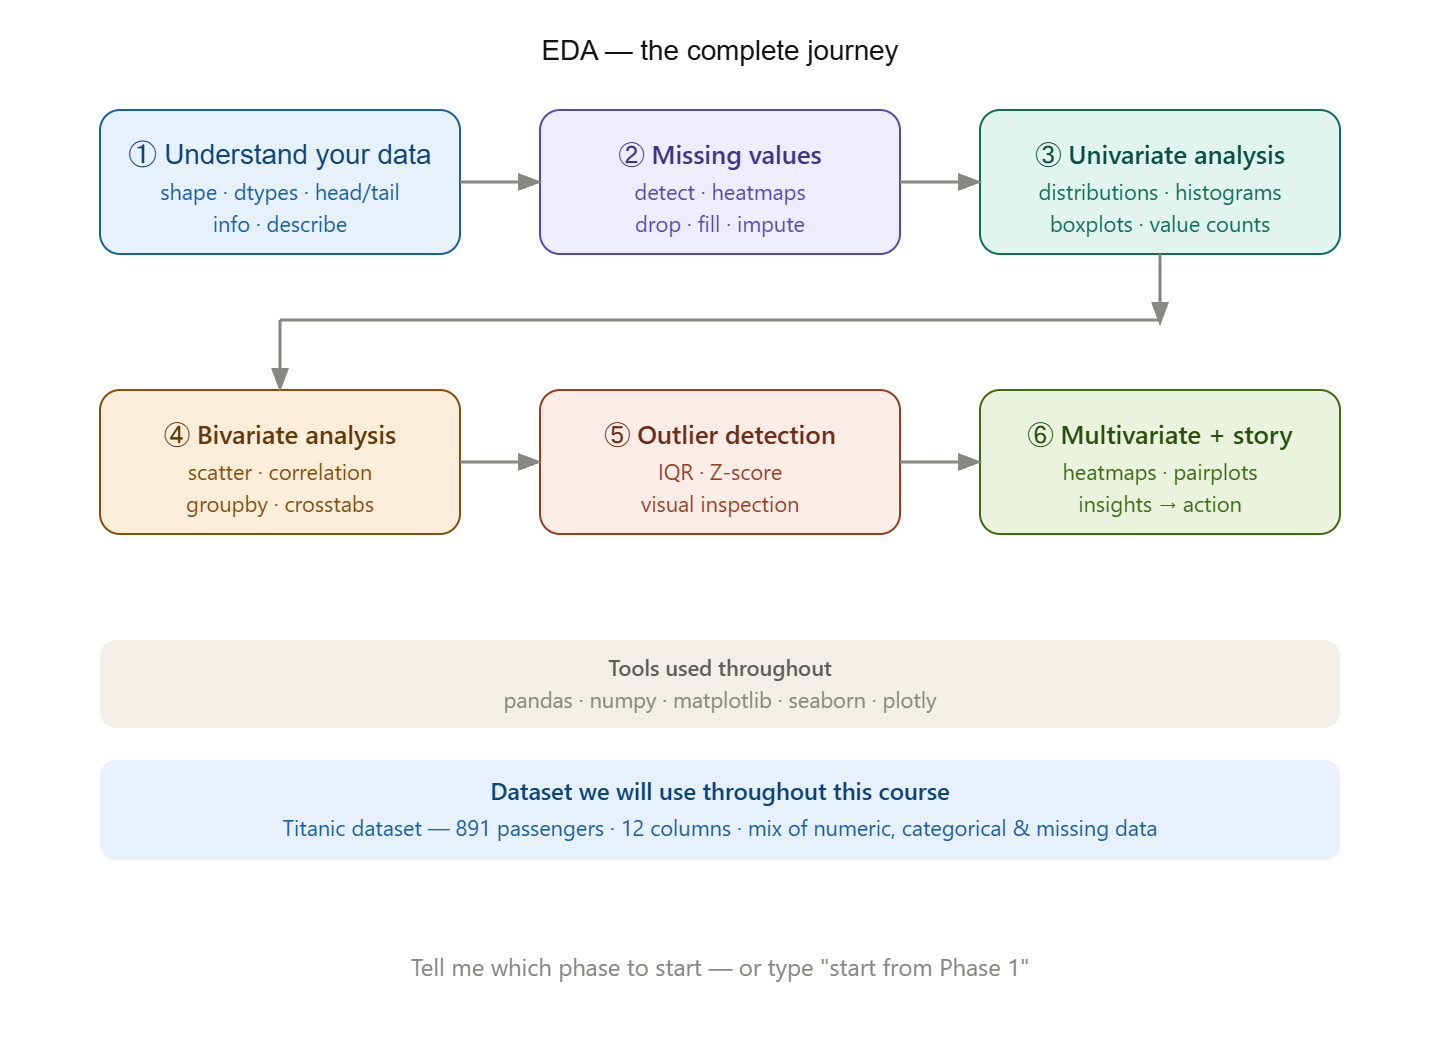

What is EDA, Professor?
EDA stands for Exploratory Data Analysis. Before you build any model, dashboard, or report — you must understand your data. EDA is the detective work you do first.
Think of it like a doctor examining a patient before prescribing medicine. You don't guess. You examine, test, and observe.

Phase 1 — Understand your data
We'll use the Titanic dataset throughout. It's real, messy, and perfect for learning.
Step 1 — Load your data

Add Titanic Data Set : Titanic Data Set is Renamed as train/test.csv

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
#df = pd.read_csv('/content/sample_data/test.csv')
# OR directly from seaborn's built-in datasets:
df = sns.load_dataset('titanic')

Step 2 — First look

In [ ]:
print("Head ",df.head())       # First 5 rows — see your data
print("\nTail ",df.tail())       # Last 5 rows — check the end
print("\n Shape", df.shape)        # (891, 15) → 891 rows, 15 columns
print("\n Columns",df.columns)      # List all column names

Head     survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Tail       survived  pclass     sex   age  sibsp  parch   fare embarked   class  \
886         0       2    male  27.0      0      0  13.00        S  Second   
887         1       1  female  19.0      0      0  3

Step 3 — Data types (the most important step beginners skip)

In [ ]:
df.dtypes
# survived      int64
# pclass        int64
# sex          object   ← categorical
# age          float64  ← has decimals (and missing values)
# fare         float64
# embarked     object

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object


In [ ]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Step 4 — Summary statistics

In [ ]:
print("Describe the DataSet \n",df.describe())
# gives you: count, mean, std, min, 25%, 50%, 75%, max
# for every numeric column — in ONE line

print("\n Describe the object\n" ,df.describe(include='object'))
# same but for text/categorical columns

Describe the DataSet 
          survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200

 Describe the object
          sex embarked  who  embark_town alive
count    891      889  891          889   891
unique     2        3    3            3     2
top     male        S  man  Southampton    no
freq     577      644  537          644   549


Step 5 — Quick info report

In [ ]:
df.info()
# tells you: column names, non-null count, dtype
# This is where you FIRST spot missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


Graph shown People Survived

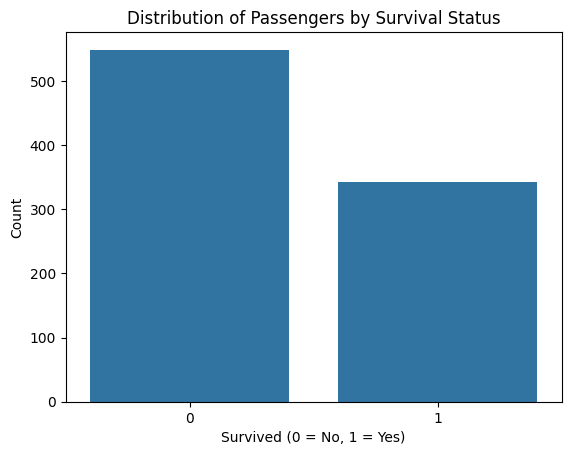

In [ ]:
sns.countplot(x='survived', data=df)
plt.title('Distribution of Passengers by Survival Status')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

Graph to show the survival by sex

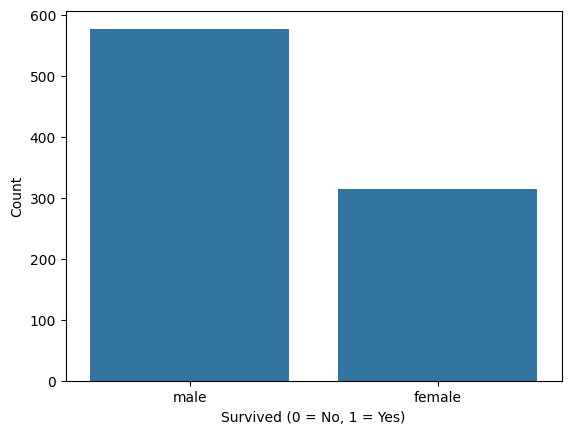

In [ ]:
sns.countplot(data=df, x='sex')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()



In [ ]:
male_survivors = df[(df['sex'] == 'male') & (df['survived'] == 1)].shape[0]
print(f"Number of male survivors: {male_survivors}")

Number of male survivors: 109


In [ ]:
print(df['survived'].value_counts())

survived
0    549
1    342
Name: count, dtype: int64


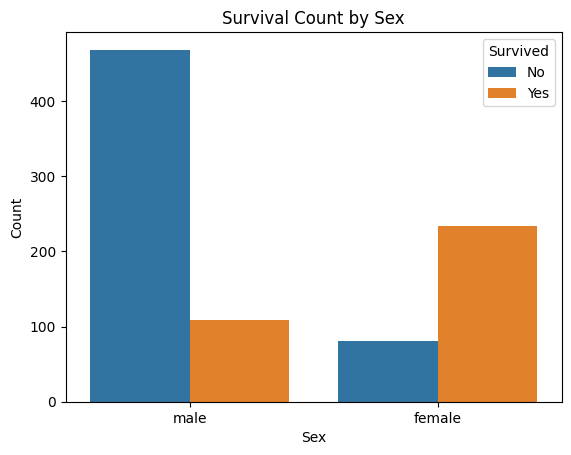

In [ ]:
sns.countplot(x='sex', hue='survived', data=df)
plt.title('Survival Count by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

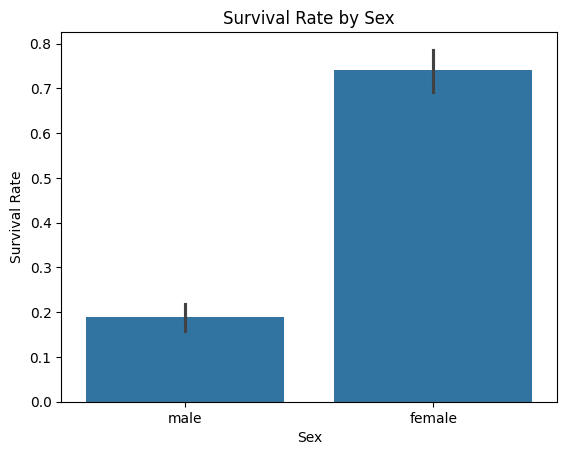

In [ ]:
#
sns.barplot(x='sex', y='survived', data=df)
plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.show()

<Axes: xlabel='sex', ylabel='count'>

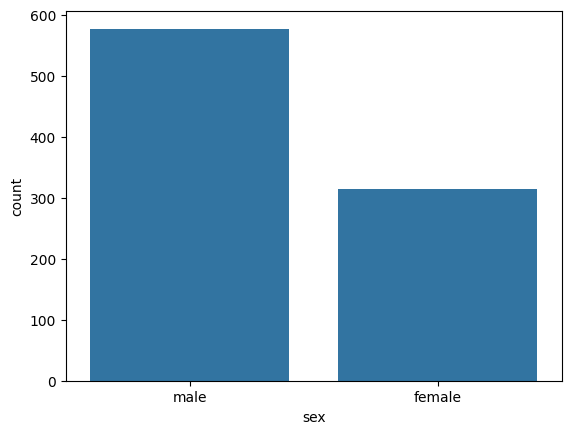

In [ ]:
sns.countplot(data = df ,x='sex')

<Axes: ylabel='count'>

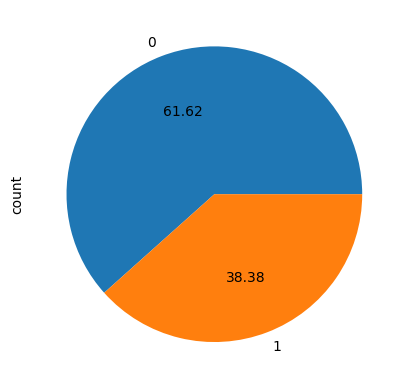

In [ ]:
from enum import auto
df['survived'].value_counts().plot(kind='pie',autopct='%.2f')


In Univarient analysis if you have categorigal data Either you go with pie chat or with bar chat


| Plot Type        | Use For                                                 | Data Type                  | Rule of Thumb                                                                                                           |
| ---------------- | ------------------------------------------------------- | -------------------------- | ----------------------------------------------------------------------------------------------------------------------- |
| **Bar Chart**    | Compare counts or aggregated values across categories   | Categorical vs Numeric     | Use when you want to compare groups (e.g., survivors by sex, average fare by class).                                    |
| **Count Plot**   | Count occurrences of categories                         | Categorical                | Use when you want to know "How many?" in each category. Seaborn does the counting automatically.                        |
| **Histogram**    | Distribution of one numeric variable                    | Numeric                    | Use to see how values are spread (e.g., Age distribution, Fare distribution).                                           |
| **Box Plot**     | Distribution + Outliers                                 | Categorical vs Numeric     | Use to compare distributions and detect outliers across groups.                                                         |
| **Scatter Plot** | Relationship between two numeric variables              | Numeric vs Numeric         | Use only when BOTH variables are numeric. Each dot represents one row. Helps find correlations, clusters, and outliers. |
| **Line Plot**    | Trends over time or ordered data                        | Ordered/Numeric            | Use when the order of points matters (time series, trends, progression).                                                |
| **Heatmap**      | Correlation and relationship strength between variables | Multiple Numeric Variables | Use when you want to see which variables are related and how strongly. Excellent for correlation analysis.              |


Do I want to count categories?
    ↓
Count Plot / Bar Chart

Do I have one numeric column and want its distribution?
    ↓
Histogram

Do I want to compare distributions across categories?
    ↓
Box Plot

Do I want to study the relationship between two numeric columns?
    ↓
Scatter Plot

Do I want to show change over time or an ordered sequence?
    ↓
Line Plot

Do I want to see correlations between many numeric variables?
    ↓
Heatmap

**The One-Liner to Remember**

Categorical data → Bar Plot / Count Plot
Pie Chat in Case of Percentage
One numeric variable → Histogram

Numeric + Categories → Box Plot

Two numeric variables → Scatter Plot

Ordered / Time data → Line Plot

Many numeric variables (correlations) → Heatmap

| Question                                                         | Best Plot                          |
| ---------------------------------------------------------------- | ---------------------------------- |
| How many males and females are there?                            | Count Plot                         |
| How many survived by sex?                                        | Count Plot (with `hue='survived'`) |
| What is the age distribution?                                    | Histogram                          |
| Are there fare outliers?                                         | Box Plot                           |
| Is there a relationship between age and fare?                    | Scatter Plot                       |
| How does survival rate change over years? (if year data existed) | Line Plot                          |


| Plot         | Matplotlib                    | Seaborn             | Usage Frequency |
| ------------ | ----------------------------- | ------------------- | --------------- |
| Bar Chart    | `plt.bar()`                   | `sns.barplot()`     | ⭐⭐⭐⭐            |
| Count Plot   | Manual counting + `plt.bar()` | `sns.countplot()`   | ⭐⭐⭐⭐⭐           |
| Histogram    | `plt.hist()`                  | `sns.histplot()`    | ⭐⭐⭐⭐⭐           |
| Scatter Plot | `plt.scatter()`               | `sns.scatterplot()` | ⭐⭐⭐⭐            |
| Line Plot    | `plt.plot()`                  | `sns.lineplot()`    | ⭐⭐⭐⭐            |
| Box Plot     | `plt.boxplot()`               | `sns.boxplot()`     | ⭐⭐⭐⭐⭐           |
| Heatmap      | Manual work                   | `sns.heatmap()`     | ⭐⭐⭐⭐⭐           |


**Syntax**

sns.countplot(x='survived', data=df)

sns.histplot(df['age'])

sns.boxplot(x='survived', y='age', data=df)

sns.scatterplot(x='age', y='fare', data=df)

sns.barplot(x='pclass', y='fare', data=df)

sns.heatmap(df.corr(numeric_only=True), annot=True)